## Import Libraries

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from galform_analysis.config import get_base_dir, DEFAULT_HALO_MASS_BINS
from galform_analysis.analysis.mass_functions import (
    hmf_given_redshift_and_subvolume,
    compute_theoretical_hmfs
)
from galform_analysis.analysis import hmfs_given_redshifts_and_subvolume

project_root = Path.cwd().parent
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root / 'src'))

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
base_dir = Path(get_base_dir())

## For a given redshift and sub volume, plot the HMF

In [2]:
halo_mass_lower_limit = 1e11

example_snapshot = 'iz207'
example_ivol = 40

hmf_result = hmf_given_redshift_and_subvolume(
    base_dir / example_snapshot,
    example_ivol,
    halo_mass_lower_limit=halo_mass_lower_limit,
    )

print(f"Loaded HMF for {hmf_result['iz']} (z={hmf_result['z']:.3f}), ivol={hmf_result['ivol']}")

Loaded HMF for iz207 (z=0.496), ivol=40


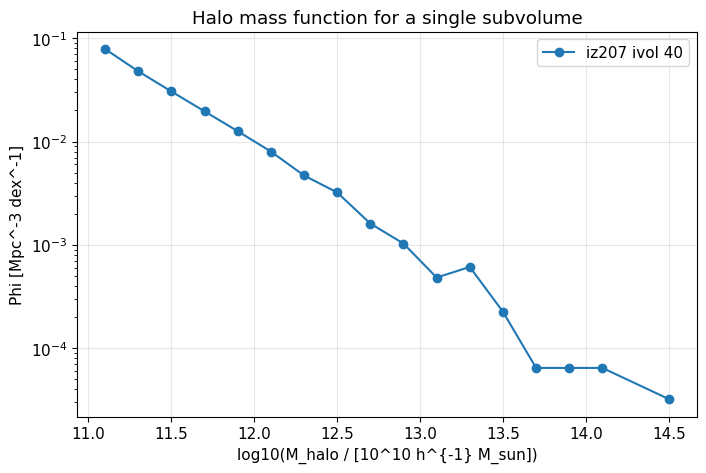

In [3]:
centers = hmf_result['centers']
phi = hmf_result['phi']
valid = np.isfinite(phi) & (phi > 0)
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_yscale('log')
ax.plot(centers[valid], phi[valid], 'o-', label=f"{hmf_result['iz']} ivol {hmf_result['ivol']}")
ax.set_xlabel("log10(M_halo / [10^10 h^{-1} M_sun])")
ax.set_ylabel("Phi [Mpc^-3 dex^-1]")
ax.set_title("Halo mass function for a single subvolume")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## For a given redshift and subvolume, compare to theoretical HMFs

In [4]:
example_snapshot = 'iz207'
example_ivol = 80
halo_mass_lower_limit = None

hmf_data = hmf_given_redshift_and_subvolume(
    base_dir / example_snapshot,
    example_ivol,
    halo_mass_lower_limit=halo_mass_lower_limit,
)

theory_bins = DEFAULT_HALO_MASS_BINS

theory_models = compute_theoretical_hmfs(
        z=hmf_data['z'],
        bins=theory_bins,
        use_mvir=True,
        include_ps_plus=True,
)
print(f"Loaded HMF for {hmf_data['iz']} (z={hmf_data['z']:.3f}), ivol={hmf_data['ivol']};", 
      f"computed {len(theory_models)} theory curves.",)

/cosma/home/durham/dc-hick2/galform_analysis/.venv/lib64/python3.9/site-packages/hmf/density_field/transfer_models.py:232: UserWarning: 'extrapolate_with_eh' was not set. Defaulting to True, which is different behaviour than versions <=3.4.4. This warning may be removed in v4.0. Silence it by setting extrapolate_with_eh explicitly.
  warnings.warn(


Loaded HMF for iz207 (z=0.496), ivol=80; computed 4 theory curves.


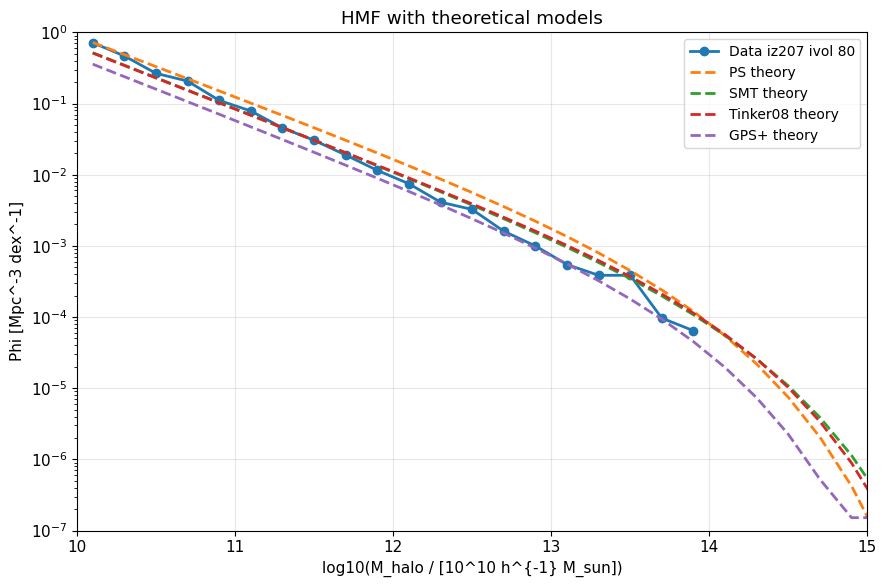

In [5]:
centers = hmf_data['centers']
phi = hmf_data['phi']
valid = np.isfinite(phi) & (phi > 0)

fig, ax = plt.subplots(figsize=(9, 6))
ax.set_yscale('log')
ax.plot(centers[valid], phi[valid], 'o-', linewidth=2, markersize=6, label=f"Data {hmf_data['iz']} ivol {hmf_data['ivol']}")

# Plot theory models - they're already interpolated to the right bins
for name, model_phi in theory_models.items():
    # Filter out invalid values
    valid_theory = np.isfinite(model_phi) & (model_phi > 0)
    ax.plot(centers[valid_theory], model_phi[valid_theory], '--', linewidth=2, label=f"{name} theory")

ax.set_xlim(10, 15)
ax.set_ylim(1e-7, 1e0)
ax.set_xlabel("log10(M_halo / [10^10 h^{-1} M_sun])")
ax.set_ylabel("Phi [Mpc^-3 dex^-1]")
ax.set_title("HMF with theoretical models")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## HMFs for different redshifts

In [6]:
halo_mass_lower_limit = 1e11

example_ivol = 40
iz_nums = [82, 100, 120]

multi_hmf_result = hmfs_given_redshifts_and_subvolume(
    example_ivol,
    iz_nums,
    base_dir=base_dir,
    halo_mass_lower_limit=halo_mass_lower_limit,
    )

hmf_df, results_by_z = multi_hmf_result
print(f"Loaded {len(results_by_z)} snapshots for ivol={example_ivol}")

Successfully loaded 3 snapshots
Loaded 3 snapshots for ivol=40


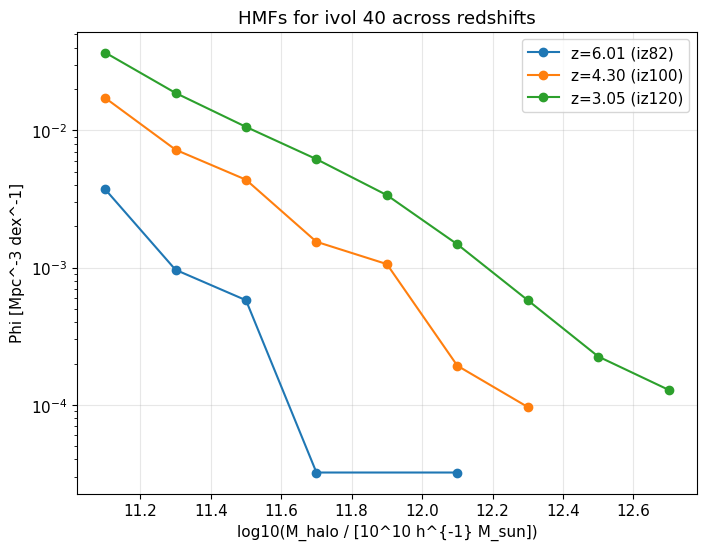

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_yscale('log')
for res in results_by_z:
    centers = res['centers']
    phi = res['phi']
    valid = np.isfinite(phi) & (phi > 0)
    ax.plot(centers[valid], phi[valid], 'o-', label=f"z={res['z']:.2f} ({res['iz']})")
ax.set_xlabel("log10(M_halo / [10^10 h^{-1} M_sun])")
ax.set_ylabel("Phi [Mpc^-3 dex^-1]")
ax.set_title(f"HMFs for ivol {example_ivol} across redshifts")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## For a given sub volume average over given redshifts

In [8]:
from galform_analysis.analysis import avg_hmf_given_redshifts_and_subvolume

example_ivol = 0  # choose a subvolume
iz_nums = [82, 100, 120]  # snapshots that exist in base_dir

avg_hmf_result = avg_hmf_given_redshifts_and_subvolume(
    example_ivol,
    iz_nums,
    halo_mass_lower_limit=halo_mass_lower_limit,
    )

print(
    f"Successfully used {avg_hmf_result['n_used']}/{avg_hmf_result['n_requested']} snapshots",
    f"ivol={avg_hmf_result['ivol']}",
    f"z range: {min(avg_hmf_result['z_list']):.2f}-{max(avg_hmf_result['z_list']):.2f}",
    sep='; '
)

Successfully used 2/3 snapshots; ivol=0; z range: 3.05-4.30


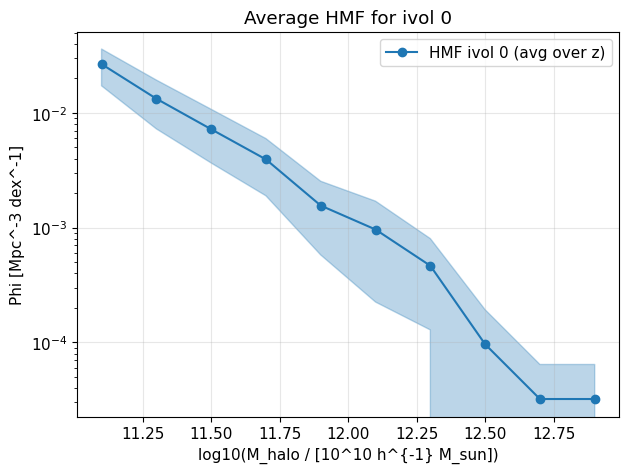

In [9]:
centers = avg_hmf_result['centers']
phi = avg_hmf_result['phi']
phi_std = avg_hmf_result['phi_std']
valid = np.isfinite(phi) & (phi > 0)
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_yscale('log')
ax.plot(centers[valid], phi[valid], 'o-', label=f"HMF ivol {avg_hmf_result['ivol']} (avg over z)", color='C0')
ax.fill_between(centers[valid], (phi - phi_std)[valid], (phi + phi_std)[valid], alpha=0.3, color='C0')
ax.set_xlabel("log10(M_halo / [10^10 h^{-1} M_sun])")
ax.set_ylabel("Phi [Mpc^-3 dex^-1]")
ax.set_title(f"Average HMF for ivol {avg_hmf_result['ivol']}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()